In [4]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [6]:
# Step 2: Load Dataset (Direct URL - No kagglehub needed)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data"
df = pd.read_csv(url, header=None)

# Assign column names
columns = ['letter'] + [f'feature_{i}' for i in range(1, 17)]
df.columns = columns

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
  letter  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      T          2          8          3          5          1          8   
1      I          5         12          3          7          2         10   
2      D          4         11          6          8          6         10   
3      N          7         11          6          6          3          5   
4      G          2          1          3          1          1          8   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0         13          0          6           6          10           8   
1          5          5          4          13           3           9   
2          6          2          6          10           3           7   
3          9          4          6           4           4          10   
4          6          6          6           6           5           9   

   feature_13  feature_14  feature_15  feature_16  
0     

In [8]:
# Step 3: Data Preprocessing
X = df.drop('letter', axis=1)
y = df['letter']

# Label Encoding (A-Z → 0-25)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# One-hot Encoding
y_categorical = to_categorical(y_encoded)

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical, test_size=0.2, random_state=42
)

In [12]:
# Step 5: Build Deep Neural Network
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(16,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output layer (26 classes)
model.add(Dense(26, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\aasth\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │           858 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,186 (31.98 KB)

 Trainable params: 8,186 (31.98 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Step 6: Train Model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5075 - loss: 1.7782 - val_accuracy: 0.7125 - val_loss: 1.0161
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7618 - loss: 0.8193 - val_accuracy: 0.7872 - val_loss: 0.7486
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8120 - loss: 0.6347 - val_accuracy: 0.8244 - val_loss: 0.6161
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8421 - loss: 0.5252 - val_accuracy: 0.8419 - val_loss: 0.5170
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8605 - loss: 0.4561 - val_accuracy: 0.8587 - val_loss: 0.4654
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8764 - loss: 0.4025 - val_accuracy: 0.8756 - val_loss: 0.4036
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8888 - loss: 0.3579 - val_accuracy: 0.8741 - val_loss: 0.3884
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8980 - loss: 0.3248 - val_accuracy: 0.

In [16]:
# Step 7: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9398 - loss: 0.1882

Test Accuracy: 0.9397500157356262


In [18]:
# Step 8: Predictions
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Accuracy Score:", accuracy_score(y_true, y_pred_classes))


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy Score: 0.93975


In [20]:
# Step 9: Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes))


Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       149
           1       0.88      0.95      0.92       153
           2       0.99      0.89      0.94       137
           3       0.91      0.97      0.94       156
           4       0.92      0.94      0.93       141
           5       0.85      0.94      0.89       140
           6       0.94      0.93      0.93       160
           7       0.93      0.83      0.88       144
           8       0.97      0.91      0.94       146
           9       0.94      0.95      0.94       149
          10       0.94      0.88      0.91       130
          11       0.97      0.94      0.95       155
          12       0.98      0.95      0.96       168
          13       0.97      0.94      0.96       151
          14       0.95      0.97      0.96       145
          15       0.96      0.91      0.93       173
          16       0.99      0.94      0.96       166
  

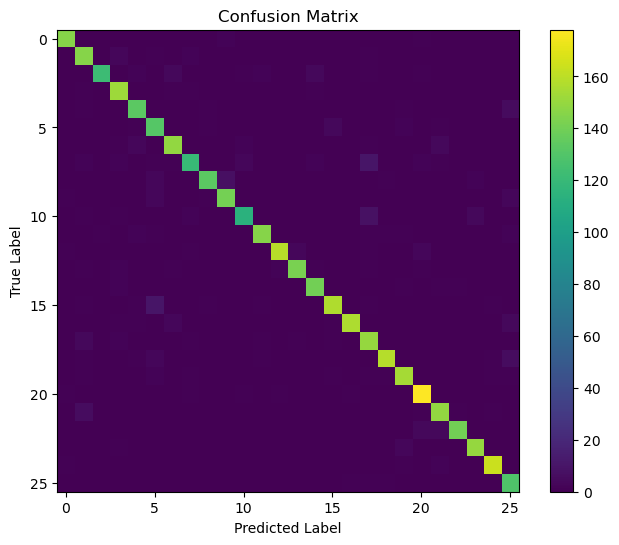

In [22]:
# Step 10: Confusion Matrix (Clean Plot)
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()